# Fase 4 — Feature stilometriche

Questo notebook **documenta** le scelte fatte in `src/features.py`; non
riesegue l'estrazione, che avviene nello script. Serve a rendere verificabili
le quattro decisioni prese durante la costruzione del set di feature, ognuna
delle quali ha modificato il codice.

**Principio guida**: set piccolo e interpretabile, 15-30 feature. Ogni
feature deve avere un nome spiegabile a voce in cinque secondi.
L'interpretabilita' non e' una preferenza estetica: senza coefficienti
leggibili l'analisi dei falsi positivi della Fase 6 sarebbe impossibile.

Il set e' passato per quattro versioni:

| versione | colonne | cambiamento |
|----------|---------|-------------|
| 1 | 35 | set iniziale |
| 2 | 34 | rimossa `punt_virgolette`, rinominate tre feature |
| 3 | 37 | aggiunte `tripletta`, `em_dash`, `en_dash` |
| 4 | 36 | rimossa `punt_per_100parole_trattino` |

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURE = RADICE / "results" / "figures"
TABELLE = RADICE / "results" / "tables"
FIGURE.mkdir(parents=True, exist_ok=True)
TABELLE.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

META = {"question_id", "question", "text", "label", "domain", "n_parole"}

f = pd.read_parquet(RADICE / "data" / "processed" / "hc3_features.parquet")
COLS = [c for c in f.columns if c not in META and f[c].dtype != object]

print(f"{len(f)} righe, {len(COLS)} feature")
print(f"Righe perse nell'estrazione: {19980 - len(f)}")

19980 righe, 30 feature
Righe perse nell'estrazione: 0


## 1. Il set di feature

Sette categorie. La divisione non e' solo espositiva: in Fase 6 serve a
capire se l'errore si concentra su una dimensione o si distribuisce.

In [2]:
categorie = {
    "lunghezza e ritmo": ["lung_frase_media", "lung_frase_std",
                          "lung_parola_media", "n_frasi"],
    "ricchezza lessicale": ["mattr", "hapax_ratio", "entropia"],
    "sintassi": ["prof_albero_media", "subordinate_per_frase",
                 "coordinate_per_frase"],
    "lessico funzionale": ["ratio_connettivi", "ratio_hedging",
                           "ratio_pron_prima_persona"],
    "distribuzione POS": [c for c in COLS if c.startswith("pos_")],
    "punteggiatura": [c for c in COLS if c.startswith("punt_")],
    "strutture tipiche": ["tripletta_per_100parole", "em_dash_per_100parole",
                          "en_dash_per_100parole"],
}

for nome, elenco in categorie.items():
    presenti = [c for c in elenco if c in COLS]
    print(f"{nome:22s} {len(presenti):2d}  {', '.join(presenti)}")

coperte = {c for elenco in categorie.values() for c in elenco}
print("\nNon categorizzate:", sorted(set(COLS) - coperte))

lunghezza e ritmo       4  lung_frase_media, lung_frase_std, lung_parola_media, n_frasi
ricchezza lessicale     3  mattr, hapax_ratio, entropia
sintassi                3  prof_albero_media, subordinate_per_frase, coordinate_per_frase
lessico funzionale      3  ratio_connettivi, ratio_hedging, ratio_pron_prima_persona
distribuzione POS       8  pos_noun, pos_verb, pos_adj, pos_adv, pos_pron, pos_adp, pos_cconj, pos_sconj
punteggiatura           6  punt_per_100parole_virgola, punt_per_100parole_puntovirgola, punt_per_100parole_duepunti, punt_per_100parole_parentesi, punt_per_100parole_esclamativo, punt_per_100parole_interrogativo
strutture tipiche       3  tripletta_per_100parole, em_dash_per_100parole, en_dash_per_100parole

Non categorizzate: []


## 2. Controlli di qualita'

Tre verifiche prima di modellare: colonne costanti, valori impossibili,
ridondanza.

### 2.1 Colonne costanti

Una feature con deviazione standard nulla non porta informazione e provoca
una divisione per zero nello standardizzatore.

**Decisione 1**: `punt_virgolette` era costante a zero, perche' le
virgolette erano gia' state rimosse da entrambe le classi in Fase 2. Feature
rimossa.

In [3]:
deviazioni = f[COLS].std().sort_values()
print("Deviazioni standard piu' basse:")
print(deviazioni.head(8).to_string())

costanti = deviazioni[deviazioni == 0]
if len(costanti):
    print("\nATTENZIONE, colonne costanti residue:", list(costanti.index))
else:
    print("\nNessuna colonna costante.")

Deviazioni standard piu' basse:
ratio_connettivi            0.003649
ratio_hedging               0.012447
ratio_pron_prima_persona    0.014405
pos_sconj                   0.014757
pos_cconj                   0.016609
pos_adv                     0.023058
pos_adp                     0.024269
pos_verb                    0.027409

Nessuna colonna costante.


Nota: una deviazione standard piccola **non** significa feature inutile.
`ratio_connettivi` ha std 0.0036 ma e' la feature con il rapporto fra medie
piu' estremo (2.41). Sono grandezze intrinsecamente piccole, non poco
informative.

### 2.2 Intervalli

Si cercano valori impossibili o nomi fuorvianti.

**Decisione 2**: `ratio_subordinate` e `ratio_coordinate` arrivavano a 28 e
11.5, valori incompatibili con un rapporto fra 0 e 1. Il codice divide per
il numero di frasi, non di token: sono **conteggi per frase**. Rinominate
`subordinate_per_frase` e `coordinate_per_frase`.

Le feature di punteggiatura, normalizzate sulle parole, sono state
moltiplicate per 100 e rinominate `punt_per_100parole_*`, cosi' si leggono
come occorrenze ogni cento parole.

In [4]:
intervalli = f[COLS].describe().T[["min", "max", "mean"]]
intervalli["nome_suggerisce_rapporto"] = intervalli.index.str.startswith(
    ("ratio_", "hapax_")
)
sospette = intervalli[
    intervalli["nome_suggerisce_rapporto"] & (intervalli["max"] > 1)
]
if len(sospette):
    print("Nomi fuorvianti (suggeriscono un rapporto ma superano 1):")
    display(sospette)
else:
    print("Nessun nome fuorviante.")

intervalli.drop(columns="nome_suggerisce_rapporto").round(3)

Nessun nome fuorviante.


,min,max,mean
lung_frase_media,4.400,156.000,21.315
tripletta_per_100parole,0.000,4.124,0.143
em_dash_per_100parole,0.000,6.452,0.006
en_dash_per_100parole,0.000,6.250,0.007
lung_frase_std,0.000,98.500,8.472
lung_parola_media,3.264,6.633,4.584
n_frasi,1.000,60.000,8.742
mattr,0.332,0.932,0.647
hapax_ratio,0.056,0.864,0.386
entropia,4.043,7.420,6.066


### 2.3 Ridondanza

Feature molto correlate ricevono pesi arbitrariamente distribuiti dalla
regressione, e i coefficienti individuali diventano difficili da leggere.

In [5]:
corr = f[COLS].corr().abs()
alte = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack().sort_values(ascending=False))
alte.head(10).round(3)

mattr                 hapax_ratio              0.810
coordinate_per_frase  pos_cconj                0.724
lung_frase_media      subordinate_per_frase    0.721
                      prof_albero_media        0.673
n_frasi               entropia                 0.630
lung_frase_media      coordinate_per_frase     0.622
prof_albero_media     coordinate_per_frase     0.533
pos_noun              pos_pron                 0.520
lung_parola_media     pos_pron                 0.466
                      pos_noun                 0.442
dtype: float64

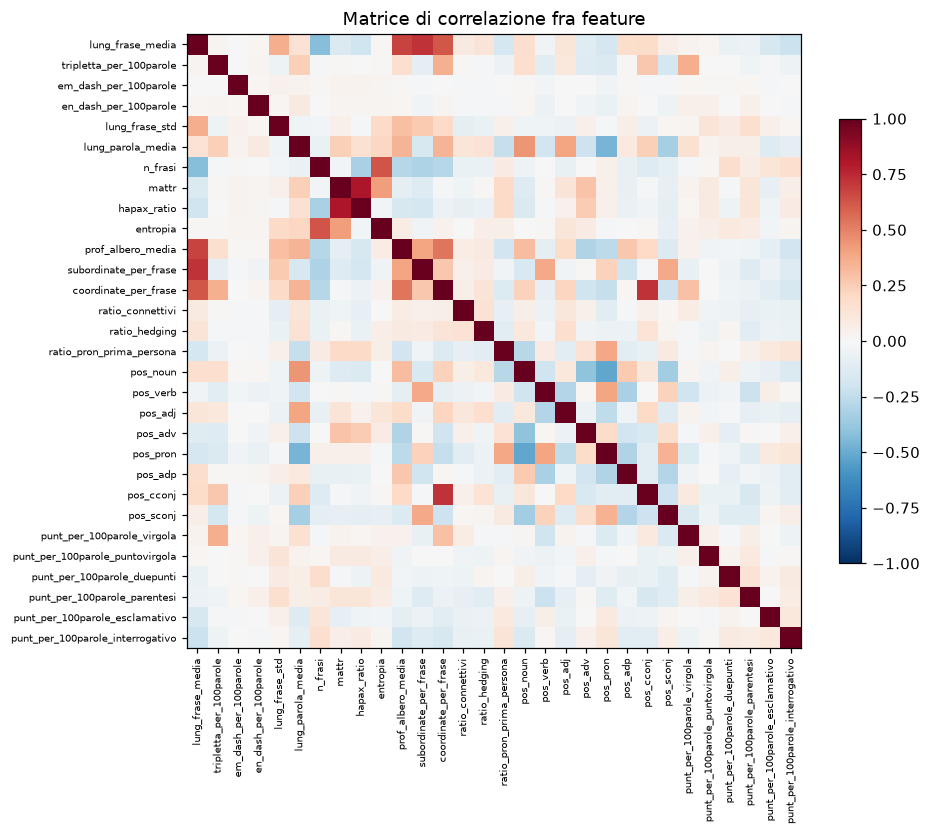

In [6]:
fig, ax = plt.subplots(figsize=(9, 7.5))
ordine = f[COLS].corr()
im = ax.imshow(ordine, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(COLS)))
ax.set_xticklabels(COLS, rotation=90, fontsize=6.5)
ax.set_yticks(range(len(COLS)))
ax.set_yticklabels(COLS, fontsize=6.5)
fig.colorbar(im, ax=ax, shrink=0.7)
ax.set_title("Matrice di correlazione fra feature")
fig.savefig(FIGURE / "03b_correlazioni.png", dpi=150, bbox_inches="tight")
plt.show()

Massimo osservato **0.81** fra `mattr` e `hapax_ratio`, entrambe misure di
ricchezza lessicale. Sotto la soglia critica: si tengono entrambe con
regolarizzazione L2, dichiarando che i loro pesi vanno letti come gruppo e
non individualmente.

`entropia` correla 0.63 con `n_frasi`: l'entropia della distribuzione di
frequenza cresce con la lunghezza del testo, quindi misura in parte la
dimensione oltre alla diversita' lessicale.

`coordinate_per_frase` e `pos_cconj` correlano 0.72 — misurano quasi la
stessa cosa da due angolazioni, la relazione sintattica e il tag POS. Questa
coppia produrra' un effetto di soppressione in Fase 5, da tenere presente
nella lettura dei coefficienti.

## 3. Ispezione degli outlier

**Decisione 3**: `punt_per_100parole_trattino` arrivava a 168.75, oltre un
trattino per parola. L'ispezione dei casi estremi ha rivelato la causa.

In [7]:
# Ricostruzione della verifica che ha portato all'esclusione.
# La feature non e' piu' nel set: si ricalcola sul testo.
f["_trattino_x100"] = 100 * f["text"].str.count("-") / f["text"].str.split().str.len()

peggiori = f.nlargest(5, "_trattino_x100")
for _, r in peggiori.iterrows():
    classe = "umano" if r["label"] == 0 else "macchina"
    print(f"[{classe}] {r['domain']} | trattini/100parole = {r['_trattino_x100']:.1f}")
    print(r["text"][:180])
    print()

print("Distribuzione per classe:")
print(f.groupby("label")["_trattino_x100"].mean().round(3).to_string())

[umano] finance | trattini/100parole = 135.4
An ISA is a much simpler thing than I suspect you think it is. It is a wrapper or envelope, and the point of it is that HMRC does not care what happens inside the envelope, or even

[umano] reddit_eli5 | trattini/100parole = 47.9
Very interesting question! I did a little calculation to determine how much data we're talking about here. So I took a random 1min video from youtube in 1080p for my assumption. I 

[umano] reddit_eli5 | trattini/100parole = 44.6
Back in the days of command - line interfaces, you bet it had a use. Imagine not having a mouse, and not having a graphic screen. Your whole computer is just a big scrolling wall o

[umano] reddit_eli5 | trattini/100parole = 42.7
Alright, lets see if I can get some ASCII graphics all up in this. I want you to imagine a triangle, where you are one point, the plane flying above you is one point, and the point

[macchina] reddit_eli5 | trattini/100parole = 37.6
Sure! A linked list is a way to 

Tutti i casi estremi sono testi umani, e i trattini sono di due tipi:

- **intervalli numerici**: `94 - 100 - A`, `97 - 100`
- **composti spezzati dal tokenizzatore di HC3**: `command - line` era
  `command-line`

Il secondo tipo e' un residuo dello stesso artefatto ripulito in Fase 2, e
colpisce **solo la classe umana** perche' solo quei testi sono passati per
il tokenizzatore. La feature misurava quindi un artefatto asimmetrico invece
dell'uso stilistico del trattino.

**Esclusa.** Coerente con la scelta della Fase 2 di non lasciare leakage
asimmetrico noto, per quanto piccolo.

In [8]:
f = f.drop(columns="_trattino_x100")

## 4. Due ipotesi sui marcatori tipici

**Decisione 4**: due intuizioni formulate a priori, prima di guardare i dati,
e poi testate. Sono state aggiunte tre feature.

### 4.1 Il trattino lungo

Ipotesi: l'eccesso di lineette e' un marcatore di testo generato.

La verifica ha richiesto di distinguere tre caratteri spesso confusi:

| carattere | nome | uso |
|-----------|------|-----|
| `-` U+002D | trattino | composti, intervalli |
| `–` U+2013 | lineetta enne | intervalli numerici |
| `—` U+2014 | lineetta emme (em dash) | inciso |

Il marcatore riconosciuto oggi e' l'**em dash**.

In [9]:
for carattere, nome in [("\u2014", "em dash"), ("\u2013", "en dash")]:
    presenza = f.groupby("label")["text"].apply(
        lambda s: s.str.contains(carattere).mean()
    )
    print(f"{nome:10s} umano={presenza[0]:.4f}  macchina={presenza[1]:.4f}  "
          f"rapporto={presenza[1] / presenza[0]:.2f}")

em dash    umano=0.0112  macchina=0.0016  rapporto=0.14
en dash    umano=0.0125  macchina=0.0026  rapporto=0.21


**Ipotesi smentita, e in modo netto**: l'em dash compare nell'1.12% dei
testi umani contro lo 0.16% di quelli generati, circa sette volte piu'
spesso. Misurato come frequenza ogni 100 parole (la feature usata dal
modello) il divario sale a circa 13 volte.

Non significa che l'osservazione sia falsa in generale: significa che il
fenomeno e' **posteriore a HC3**. Il corpus e' di dicembre 2022, costruito
con la prima versione pubblica di ChatGPT; la prevalenza dell'em dash e' un
tratto dei modelli successivi, plausibilmente indotto da un RLHF che premia
prosa discorsiva.

Il risultato sostiene H3 su un asse non previsto:

> Le spie stilistiche non sono stabili nel tempo. Un detector addestrato su
> un generatore cerca tratti che generatori successivi possono non avere, o
> avere invertiti.

Le due feature sono state aggiunte al set: hanno rapporti di 0.07 e 0.15,
fra i piu' estremi osservati.

### 4.2 Gli elenchi di tre

Ipotesi: la struttura `X, Y, and Z` e' tipica del testo generato.

L'evidenza indiretta c'era gia': `coordinate_per_frase` ha rapporto 1.49 e
`pos_cconj` 1.35. La regex la rende esplicita.

In [10]:
import re

RE_TRIPLETTA = re.compile(r"\b\w+, \w+,? and \w+\b")

conteggio = f.groupby("label")["text"].apply(
    lambda s: s.map(lambda t: len(RE_TRIPLETTA.findall(t))).mean()
)
print(f"Triplette per testo: umano={conteggio[0]:.3f}  "
      f"macchina={conteggio[1]:.3f}  rapporto={conteggio[1] / conteggio[0]:.2f}")

Triplette per testo: umano=0.160  macchina=0.340  rapporto=2.12


**Ipotesi confermata**: rapporto 2.12 sui conteggi grezzi, 2.01 sulla
feature normalizzata — secondo posto assoluto fra i marcatori di
generazione, dopo `ratio_connettivi`.

La regex e' volutamente grezza: cattura solo triplette di parole singole e
perde quelle con sintagmi lunghi. Il segnale reale e' presumibilmente piu'
forte di quanto misurato. E' un limite da dichiarare, non un difetto da
correggere: una regex piu' permissiva sarebbe piu' difficile da giustificare.

**Le due ipotesi a confronto**: una smentita, una confermata. Il fatto che
il test abbia potuto fallire, e in un caso sia fallito, e' cio' che lo rende
un test.

## 5. Medie per classe

Il quadro complessivo prima di qualunque addestramento.

In [11]:
sintesi = f.groupby("label")[COLS].mean().T
sintesi.columns = ["umano", "macchina"]
sintesi["rapporto"] = sintesi["macchina"] / sintesi["umano"]
sintesi = sintesi.sort_values("rapporto")
sintesi.to_csv(TABELLE / "feature_medie_per_classe.csv")
sintesi.round(4)

,umano,macchina,rapporto
punt_per_100parole_puntovirgola,0.1000,0.0030,0.0300
em_dash_per_100parole,0.0113,0.0008,0.0747
en_dash_per_100parole,0.0117,0.0018,0.1520
punt_per_100parole_parentesi,0.8370,0.2156,0.2576
ratio_pron_prima_persona,0.0108,0.0032,0.2951
punt_per_100parole_interrogativo,0.1570,0.0497,0.3167
pos_adv,0.0508,0.0341,0.6719
hapax_ratio,0.4426,0.3288,0.7429
lung_frase_std,9.3758,7.5679,0.8072
n_frasi,9.4278,8.0556,0.8544


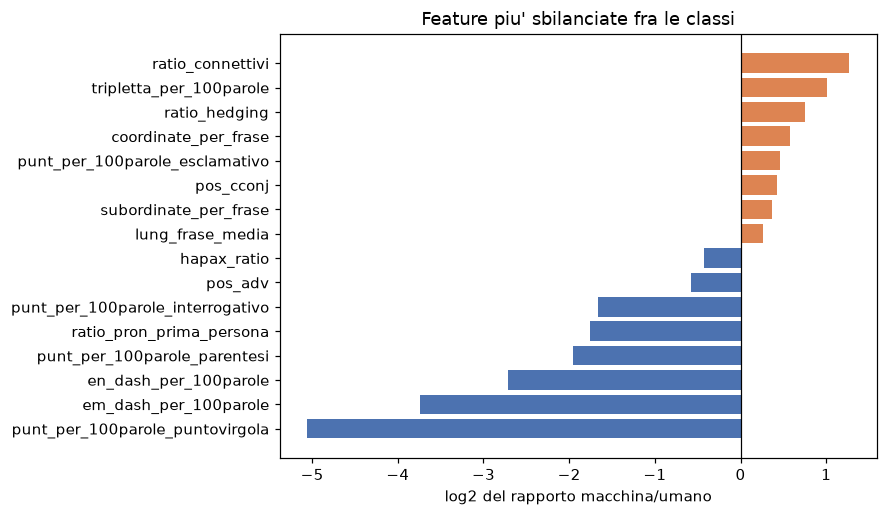

In [12]:
estremi = pd.concat([sintesi.head(8), sintesi.tail(8)])
colori = ["#4C72B0" if r < 1 else "#DD8452" for r in estremi["rapporto"]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(estremi.index, np.log2(estremi["rapporto"]), color=colori)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("log2 del rapporto macchina/umano")
ax.set_title("Feature piu' sbilanciate fra le classi")
fig.savefig(FIGURE / "03c_medie_per_classe.png", dpi=150, bbox_inches="tight")
plt.show()

### I due ritratti

**Testo generato**: piu' connettivi espliciti (2.41), piu' triplette (2.01),
piu' hedging (1.69), piu' coordinazione (1.49), frasi piu' lunghe
(19.4 → 23.3 parole), alberi sintattici piu' profondi (1.15).

**Testo umano**: punto e virgola (0.03), em dash (0.07), parentesi (0.26),
prima persona (0.30), domande (0.32), avverbi (0.67), maggiore varieta'
lessicale (hapax 0.74) e **maggiore variabilita' del ritmo**
(`lung_frase_std` 0.81).

L'ultimo punto e' il piu' rilevante per H2. Il testo generato non differisce
solo nella media ma e' piu' **regolare**. Ne segue una previsione
verificabile: un umano che scrive in modo uniforme e formale — chi scrive
prosa tecnica, editata, o in una seconda lingua con struttura controllata —
avra' il profilo della macchina, e sara' sistematicamente penalizzato.

E' l'ipotesi che la Fase 6 va a verificare.

## 6. Previsione per la Fase 5

Registrata **prima** di addestrare qualunque modello. Da non modificare dopo
aver visto i coefficienti.

In [13]:
previsione = {
    "verso macchina": ["ratio_connettivi", "tripletta_per_100parole",
                       "ratio_hedging", "coordinate_per_frase"],
    "verso umano": ["punt_per_100parole_puntovirgola", "em_dash_per_100parole",
                    "punt_per_100parole_parentesi", "ratio_pron_prima_persona"],
}

nota = """
Ci si attende che il modello pesi in direzione "macchina" ratio_connettivi,
tripletta_per_100parole, ratio_hedging e coordinate_per_frase; in direzione
"umano" punt_per_100parole_puntovirgola, em_dash_per_100parole,
punt_per_100parole_parentesi e ratio_pron_prima_persona.

Se i coefficienti si discostano da questo ordine, la differenza va spiegata:
le medie marginali ignorano le correlazioni fra feature, che la regressione
invece tiene in conto. Una feature molto correlata con un'altra puo'
ricevere peso basso, o persino segno opposto, pur avendo medie molto diverse
fra le classi (effetto di soppressione).
"""

import json
(TABELLE / "previsione_fase5.json").write_text(
    json.dumps(previsione, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(nota)


Ci si attende che il modello pesi in direzione "macchina" ratio_connettivi,
tripletta_per_100parole, ratio_hedging e coordinate_per_frase; in direzione
"umano" punt_per_100parole_puntovirgola, em_dash_per_100parole,
punt_per_100parole_parentesi e ratio_pron_prima_persona.

Se i coefficienti si discostano da questo ordine, la differenza va spiegata:
le medie marginali ignorano le correlazioni fra feature, che la regressione
invece tiene in conto. Una feature molto correlata con un'altra puo'
ricevere peso basso, o persino segno opposto, pur avendo medie molto diverse
fra le classi (effetto di soppressione).



## 7. Riepilogo delle decisioni

| # | decisione | motivazione |
|---|-----------|-------------|
| 1 | rimossa `punt_virgolette` | costante a zero dopo la pulizia di Fase 2 |
| 2 | rinominate `subordinate_per_frase`, `coordinate_per_frase`, `punt_per_100parole_*` | i nomi precedenti suggerivano rapporti fra 0 e 1, mentre sono conteggi |
| 3 | rimossa `punt_per_100parole_trattino` | misurava intervalli numerici e composti spezzati dal tokenizzatore, artefatto presente solo nella classe umana |
| 4 | aggiunte `em_dash`, `en_dash`, `tripletta` | due ipotesi formulate a priori, una smentita e una confermata |

Nessuna di queste decisioni e' stata presa guardando le prestazioni di un
classificatore: al momento della Fase 4 nessun modello era stato ancora
addestrato.